# Exploração Inicial do Limit Order Book (LOB)

Este notebook serve como ponto de partida para:
- carregar dados da B3 (ex.: CSV em `../data/`)
- inspecionar o livro de ofertas (LOB)
- preparar features para o ambiente `B3LimitOrderBookEnv` e para a rede MoE.

In [1]:
# Configuração de caminho para importar o pacote local `src`
import sys
from pathlib import Path

ROOT_DIR = Path('..').resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

In [2]:
# Importações padrão de Data Science
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

# Importando as nossas classes do diretório src
from src.sor_env import MultiVenueSOREnv
from src.moe_dqn import MoENetwork

# Configurando o PyTorch para não usar notação científica (facilita a leitura)
torch.set_printoptions(sci_mode=False, precision=4)

### Criação dos Dados Simulados (LOB)

In [3]:
# Criando DataFrames simulando 10 milissegundos do Limit Order Book - Level 2
# B3
lob_b3_data = {
    'ask_1': [35.00, 35.01, 35.02, 34.99, 35.05, 35.04, 35.06, 35.03, 35.07, 35.08],
    'vol_ask_1': [1500, 2000, 800, 3000, 500, 1200, 400, 2500, 300, 100],
    'ask_2': [35.01, 35.02, 35.03, 35.00, 35.06, 35.05, 35.07, 35.04, 35.08, 35.09],
    'vol_ask_2': [1000, 1500, 1200, 2500, 700, 800, 350, 2000, 250, 80],
    'ask_3': [35.02, 35.03, 35.04, 35.01, 35.07, 35.06, 35.08, 35.05, 35.09, 35.10],
    'vol_ask_3': [800, 1000, 1000, 2000, 600, 600, 300, 1500, 200, 60],
    'ask_4': [35.03, 35.04, 35.05, 35.02, 35.08, 35.07, 35.09, 35.06, 35.10, 35.11],
    'vol_ask_4': [600, 800, 800, 1500, 500, 400, 250, 1000, 150, 50],
    'ask_5': [35.04, 35.05, 35.06, 35.03, 35.09, 35.08, 35.10, 35.07, 35.11, 35.12],
    'vol_ask_5': [500, 600, 600, 1000, 400, 300, 200, 800, 100, 40],
    'bid_1': [34.98, 34.99, 35.00, 34.97, 35.03, 35.02, 35.04, 35.01, 35.05, 35.06],
    'vol_bid_1': [1400, 1900, 750, 2900, 480, 1150, 380, 2400, 280, 90],
    'bid_2': [34.97, 34.98, 34.99, 34.96, 35.02, 35.01, 35.03, 35.00, 35.04, 35.05],
    'vol_bid_2': [950, 1400, 1150, 2400, 650, 750, 320, 1900, 230, 75],
    'bid_3': [34.96, 34.97, 34.98, 34.95, 35.01, 35.00, 35.02, 34.99, 35.03, 35.04],
    'vol_bid_3': [750, 950, 950, 1900, 580, 580, 280, 1400, 180, 55],
    'bid_4': [34.95, 34.96, 34.97, 34.94, 35.00, 34.99, 35.01, 34.98, 35.02, 35.03],
    'vol_bid_4': [550, 750, 750, 1400, 480, 380, 230, 950, 140, 45],
    'bid_5': [34.94, 34.95, 34.96, 34.93, 34.99, 34.98, 35.00, 34.97, 35.01, 35.02],
    'vol_bid_5': [450, 550, 550, 950, 380, 280, 180, 750, 90, 35],
}
df_b3 = pd.DataFrame(lob_b3_data)

# Base Exchange
lob_base_data = {
    'ask_1': [35.02, 35.03, 35.05, 35.01, 35.06, 35.05, 35.08, 35.04, 35.09, 35.10],
    'vol_ask_1': [1200, 1800, 1000, 2800, 600, 1000, 350, 2300, 280, 95],
    'ask_2': [35.03, 35.04, 35.06, 35.02, 35.07, 35.06, 35.09, 35.05, 35.10, 35.11],
    'vol_ask_2': [900, 1200, 900, 2200, 550, 700, 300, 1800, 230, 70],
    'ask_3': [35.04, 35.05, 35.07, 35.03, 35.08, 35.07, 35.10, 35.06, 35.11, 35.12],
    'vol_ask_3': [700, 900, 800, 1800, 450, 500, 250, 1300, 180, 55],
    'ask_4': [35.05, 35.06, 35.08, 35.04, 35.09, 35.08, 35.11, 35.07, 35.12, 35.13],
    'vol_ask_4': [500, 700, 700, 1300, 350, 350, 200, 900, 130, 45],
    'ask_5': [35.06, 35.07, 35.09, 35.05, 35.10, 35.09, 35.12, 35.08, 35.13, 35.14],
    'vol_ask_5': [400, 500, 500, 900, 250, 250, 150, 650, 80, 35],
    'bid_1': [35.00, 35.01, 35.03, 34.99, 35.04, 35.03, 35.06, 35.02, 35.07, 35.08],
    'vol_bid_1': [1100, 1700, 950, 2700, 580, 950, 330, 2200, 260, 85],
    'bid_2': [34.99, 35.00, 35.02, 34.98, 35.03, 35.02, 35.05, 35.01, 35.06, 35.07],
    'vol_bid_2': [850, 1100, 850, 2100, 520, 650, 280, 1700, 210, 65],
    'bid_3': [34.98, 34.99, 35.01, 34.97, 35.02, 35.01, 35.04, 35.00, 35.05, 35.06],
    'vol_bid_3': [650, 850, 750, 1700, 420, 450, 230, 1200, 160, 50],
    'bid_4': [34.97, 34.98, 35.00, 34.96, 35.01, 35.00, 35.03, 34.99, 35.04, 35.05],
    'vol_bid_4': [450, 650, 650, 1200, 320, 320, 180, 850, 120, 40],
    'bid_5': [34.96, 34.97, 34.99, 34.95, 35.00, 34.99, 35.02, 34.98, 35.03, 35.04],
    'vol_bid_5': [350, 450, 450, 850, 230, 230, 130, 600, 70, 30],
}
df_base = pd.DataFrame(lob_base_data)

print("=== LIMIT ORDER BOOK - B3 ===")
print("Primeiros ticks do LOB B3:")
display(df_b3.head())

print("\n=== LIMIT ORDER BOOK - BASE EXCHANGE ===")
print("Primeiros ticks do LOB Base Exchange:")
display(df_base.head())

=== LIMIT ORDER BOOK - B3 ===
Primeiros ticks do LOB B3:


,ask_1,vol_ask_1,ask_2,vol_ask_2,ask_3,vol_ask_3,ask_4,vol_ask_4,ask_5,vol_ask_5,bid_1,vol_bid_1,bid_2,vol_bid_2,bid_3,vol_bid_3,bid_4,vol_bid_4,bid_5,vol_bid_5
0,35.00,1500,35.01,1000,35.02,800,35.03,600,35.04,500,34.98,1400,34.97,950,34.96,750,34.95,550,34.94,450
1,35.01,2000,35.02,1500,35.03,1000,35.04,800,35.05,600,34.99,1900,34.98,1400,34.97,950,34.96,750,34.95,550
2,35.02,800,35.03,1200,35.04,1000,35.05,800,35.06,600,35.00,750,34.99,1150,34.98,950,34.97,750,34.96,550
3,34.99,3000,35.00,2500,35.01,2000,35.02,1500,35.03,1000,34.97,2900,34.96,2400,34.95,1900,34.94,1400,34.93,950
4,35.05,500,35.06,700,35.07,600,35.08,500,35.09,400,35.03,480,35.02,650,35.01,580,35.00,480,34.99,380



=== LIMIT ORDER BOOK - BASE EXCHANGE ===
Primeiros ticks do LOB Base Exchange:


,ask_1,vol_ask_1,ask_2,vol_ask_2,ask_3,vol_ask_3,ask_4,vol_ask_4,ask_5,vol_ask_5,bid_1,vol_bid_1,bid_2,vol_bid_2,bid_3,vol_bid_3,bid_4,vol_bid_4,bid_5,vol_bid_5
0,35.02,1200,35.03,900,35.04,700,35.05,500,35.06,400,35.00,1100,34.99,850,34.98,650,34.97,450,34.96,350
1,35.03,1800,35.04,1200,35.05,900,35.06,700,35.07,500,35.01,1700,35.00,1100,34.99,850,34.98,650,34.97,450
2,35.05,1000,35.06,900,35.07,800,35.08,700,35.09,500,35.03,950,35.02,850,35.01,750,35.00,650,34.99,450
3,35.01,2800,35.02,2200,35.03,1800,35.04,1300,35.05,900,34.99,2700,34.98,2100,34.97,1700,34.96,1200,34.95,850
4,35.06,600,35.07,550,35.08,450,35.09,350,35.10,250,35.04,580,35.03,520,35.02,420,35.01,320,35.00,230


### Instanciando o Ambiente Multi-Venue SOR
O ambiente simula Smart Order Routing em um mercado fragmentado (B3 + Base Exchange).

In [4]:
# Inicializa o ambiente com uma ordem institucional de 5.000 ações
# Usa os dois LOBs: B3 e Base Exchange
from src.sor_env import MultiVenueSOREnv

env = MultiVenueSOREnv(lob_b3=df_b3, lob_base=df_base, total_inventory=5000)

# Dá o reset para capturar o primeiro estado do mercado
estado_atual, info = env.reset()

print("--- ESTADO INICIAL DO AMBIENTE ---")
print(f"Vetor de Estado [Ask_B3, Vol_B3, Ask_Base, Vol_Base, Inventário]: {estado_atual}")
print(f"Inventário Restante: {info['inventory_left']} ações")
print(f"Preço de Chegada (Benchmark): R$ {env.arrival_price:.2f}")
print(f"\nMelhor Ask na B3: R$ {df_b3.iloc[0]['ask_1']:.2f}")
print(f"Melhor Ask na Base: R$ {df_base.iloc[0]['ask_1']:.2f}")

--- ESTADO INICIAL DO AMBIENTE ---
Vetor de Estado [Ask_B3, Vol_B3, Ask_Base, Vol_Base, Inventário]: [  35.   1500.     35.02 1200.   5000.  ]
Inventário Restante: 5000 ações
Preço de Chegada (Benchmark): R$ 35.00

Melhor Ask na B3: R$ 35.00
Melhor Ask na Base: R$ 35.02


### Instanciando a Inteligência Artificial (MoE)

In [5]:
# Inicializa a rede neural Mixture of Experts
# 5 entradas (tamanho do estado: Ask_B3, Vol_B3, Ask_Base, Vol_Base, Inventário)
# 4 saídas (ações possíveis: Aguardar, Comprar B3, Comprar Base, Slicing)
# 3 especialistas
agente_moe = MoENetwork(input_dim=5, output_dim=4, num_experts=3)

print("--- ARQUITETURA DA REDE MoE ---")
print(agente_moe)

--- ARQUITETURA DA REDE MoE ---
MoENetwork(
  (gating_network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
  (experts): ModuleList(
    (0-2): 3 x SingleExpert(
      (network): Sequential(
        (0): Linear(in_features=5, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=4, bias=True)
      )
    )
  )
)


### A Mágica da Integração (O Agente "Pensa")

In [6]:
# 1. O PyTorch exige que o estado seja um Tensor. 
# Usamos unsqueeze(0) para simular um "lote" (batch) de 1 única linha.
estado_tensor = torch.tensor(estado_atual, dtype=torch.float32).unsqueeze(0)

# 2. Passamos o estado do mercado pela Rede Neural (Forward Pass)
# Usamos torch.no_grad() porque não estamos treinando a rede agora, apenas usando para prever.
with torch.no_grad():
    q_values = agente_moe(estado_tensor)

    # A rede de chaveamento (Gating Network) decide os pesos dos especialistas
    pesos_especialistas = torch.softmax(agente_moe.gating_network(estado_tensor), dim=-1)

print("--- O CÉREBRO DO AGENTE EM AÇÃO ---")
print(f"Pesos dados pelo Gerente aos 3 Especialistas: {pesos_especialistas.numpy()[0]}")
print(f"Q-Values gerados (Pontuação para cada ação): {q_values.numpy()[0]}")

# 3. O agente escolhe a ação com a maior pontuação (maior Q-Value)
acao_escolhida = torch.argmax(q_values).item()

mapa_acoes = {
    0: "Aguardar",
    1: "Comprar 100 na B3",
    2: "Comprar 100 na Base Exchange",
    3: "Slicing (100 B3 + 100 Base)"
}
print(f"\n=> Decisão da IA: Ação {acao_escolhida} ({mapa_acoes[acao_escolhida]})")

--- O CÉREBRO DO AGENTE EM AÇÃO ---
Pesos dados pelo Gerente aos 3 Especialistas: [0. 0. 1.]
Q-Values gerados (Pontuação para cada ação): [ 295.04178 -265.67212  222.21458   86.88026]

=> Decisão da IA: Ação 0 (Aguardar)


### Executando a Ação no Mercado

In [7]:
# 4. Enviamos a decisão da IA de volta para o ambiente (B3 e Base Exchange)
# Ações: 0 = Aguardar, 1 = Comprar 100 na B3, 2 = Comprar 100 na Base, 3 = Slicing (100+100)
proximo_estado, recompensa, terminado, truncado, info_step = env.step(acao_escolhida)

# Garantindo que a chave solicitada exista no dicionário info para o print não falhar
info_step['inventory_left'] = env.inventory_remaining 

mapa_acoes_detalhado = {
    0: "Aguardar",
    1: "Comprar 100 na B3",
    2: "Comprar 100 na Base Exchange",
    3: "Slicing (100 na B3 + 100 na Base)"
}

print("--- RESULTADO DA EXECUÇÃO ---")
print(f"Ação Executada: {mapa_acoes_detalhado.get(acao_escolhida, 'Desconhecida')}")
print(f"Recompensa (Slippage/Cost): {recompensa:.4f}")
print(f"Inventário Restante: {info_step['inventory_left']} ações")
print(f"Novo Estado do Mercado: {proximo_estado}")
print(f"Episódio Terminado: {terminado}")
print(f"Episódio Truncado: {truncado}")

--- RESULTADO DA EXECUÇÃO ---
Ação Executada: Aguardar
Recompensa (Slippage/Cost): 0.0000
Inventário Restante: 5000.0 ações
Novo Estado do Mercado: [  35.01 2000.     35.03 1800.   5000.  ]
Episódio Terminado: False
Episódio Truncado: False


### Simulação Completa (TWAP vs IA)


In [8]:
# 1) Funcoes auxiliares para comparacao TWAP vs IA

def run_twap_baseline(env_sim, total_qty):
    """Executa TWAP roteando apenas para B3."""
    env_sim.reset()
    env_sim.inventory_remaining = total_qty

    # Usa len-1 para manter compatibilidade com a logica de termino do ambiente
    steps_disponiveis = max(1, len(env_sim.lob_b3) - 1)
    qty_per_step = max(1, total_qty // steps_disponiveis)

    custo_total = 0.0
    vol_executado = 0.0

    for step in range(steps_disponiveis):
        if env_sim.inventory_remaining <= 0:
            break

        row_b3 = env_sim.lob_b3.iloc[step]
        vol_to_buy = min(qty_per_step, env_sim.inventory_remaining)
        exec_result = env_sim._execute_order(vol_to_buy, row_b3)

        custo_total += exec_result.cost
        vol_executado += exec_result.volume_executed
        env_sim.inventory_remaining -= exec_result.volume_executed

    preco_medio = custo_total / vol_executado if vol_executado > 0 else 0.0
    return float(preco_medio), float(vol_executado)


def run_ia_agent(env_sim, model, total_qty):
    """Executa o agente IA ate terminar episodio ou acabar janela valida de indices."""
    estado, _ = env_sim.reset()
    env_sim.inventory_remaining = total_qty

    custo_total = 0.0
    vol_executado = 0.0
    acoes_tomadas = []
    pesos_historico = []

    done = False
    while (not done) and env_sim.inventory_remaining > 0 and env_sim.current_step < len(env_sim.lob_b3) - 1:
        estado_tensor = torch.tensor(estado, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            q_values = model(estado_tensor)
            pesos = torch.softmax(model.gating_network(estado_tensor), dim=-1)

        acao = torch.argmax(q_values).item()
        acoes_tomadas.append(acao)
        pesos_historico.append(pesos.numpy()[0])

        inv_antes = env_sim.inventory_remaining
        estado, recompensa, terminated, truncated, _ = env_sim.step(acao)
        done = terminated or truncated

        vol_step = inv_antes - env_sim.inventory_remaining
        if vol_step > 0:
            preco_executado = env_sim.arrival_price - (recompensa / vol_step)
            custo_total += preco_executado * vol_step
            vol_executado += vol_step

    preco_medio = custo_total / vol_executado if vol_executado > 0 else 0.0
    return float(preco_medio), float(vol_executado), acoes_tomadas, np.array(pesos_historico)

In [9]:
# 2) Executando as simulacoes (ordem de 1000 acoes para os 10 steps do mock)
TOTAL_ORDER = 1000
preco_twap, vol_twap = run_twap_baseline(env, TOTAL_ORDER)
preco_ia, vol_ia, historico_acoes, historico_pesos = run_ia_agent(env, agente_moe, TOTAL_ORDER)

print(f"TWAP -> Preco Medio: R$ {preco_twap:.4f} | Volume Executado: {vol_twap}")
print(f"IA   -> Preco Medio: R$ {preco_ia:.4f} | Volume Executado: {vol_ia}")

TWAP -> Preco Medio: R$ 35.0300 | Volume Executado: 999.0
IA   -> Preco Medio: R$ 0.0000 | Volume Executado: 0.0


### Gráficos de Comparação Financeira (Slippage)


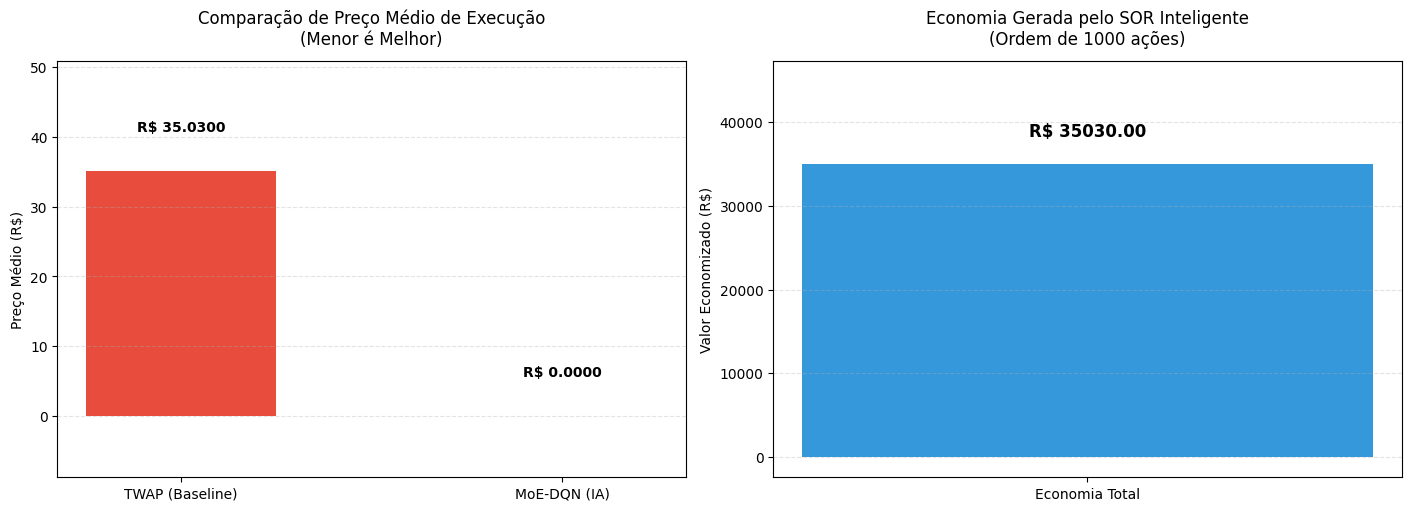

In [10]:
# Gráficos de Comparação Financeira (Slippage)
# Merge: estilo original + ajustes de layout para evitar sobreposição
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Gráfico 1: Preço Médio
labels = ['TWAP (Baseline)', 'MoE-DQN (IA)']
precos = [preco_twap, preco_ia]
cores = ['#e74c3c', '#2ecc71']

bars = ax1.bar(labels, precos, color=cores, width=0.5)
ax1.set_title('Comparação de Preço Médio de Execução\n(Menor é Melhor)', fontsize=12, pad=12)
ax1.set_ylabel('Preço Médio (R$)')

# Faixa com margem dinâmica (evita texto cortado quando os valores ficam próximos)
min_preco = min(precos)
max_preco = max(precos)
faixa_preco = max(max_preco - min_preco, 1e-6)
ax1.set_ylim(min_preco - 0.25 * faixa_preco, max_preco + 0.45 * faixa_preco)

for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.15 * faixa_preco,
        f'R$ {yval:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Gráfico 2: Economia Total
economia_por_acao = preco_twap - preco_ia
economia_total = economia_por_acao * TOTAL_ORDER

bars2 = ax2.bar(['Economia Total'], [economia_total], color='#3498db', width=0.3)
ax2.set_title(f'Economia Gerada pelo SOR Inteligente\n(Ordem de {TOTAL_ORDER} ações)', fontsize=12, pad=12)
ax2.set_ylabel('Valor Economizado (R$)')

# Ajuste para positivo/negativo sem sobreposição do label
margem = max(abs(economia_total) * 0.35, 0.5)
if economia_total >= 0:
    ax2.set_ylim(-margem * 0.2, economia_total + margem)
    y_text = economia_total + max(abs(economia_total) * 0.08, 0.15)
    va_text = 'bottom'
else:
    ax2.set_ylim(economia_total - margem, margem * 0.2)
    y_text = economia_total - max(abs(economia_total) * 0.08, 0.15)
    va_text = 'top'

ax2.text(
    bars2[0].get_x() + bars2[0].get_width() / 2,
    y_text,
    f'R$ {economia_total:.2f}',
    ha='center',
    va=va_text,
    fontsize=12,
    fontweight='bold'
)

ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax2.grid(axis='y', linestyle='--', alpha=0.35)

plt.show()

### Análise da Arquitetura MoE e Distribuição de Ações


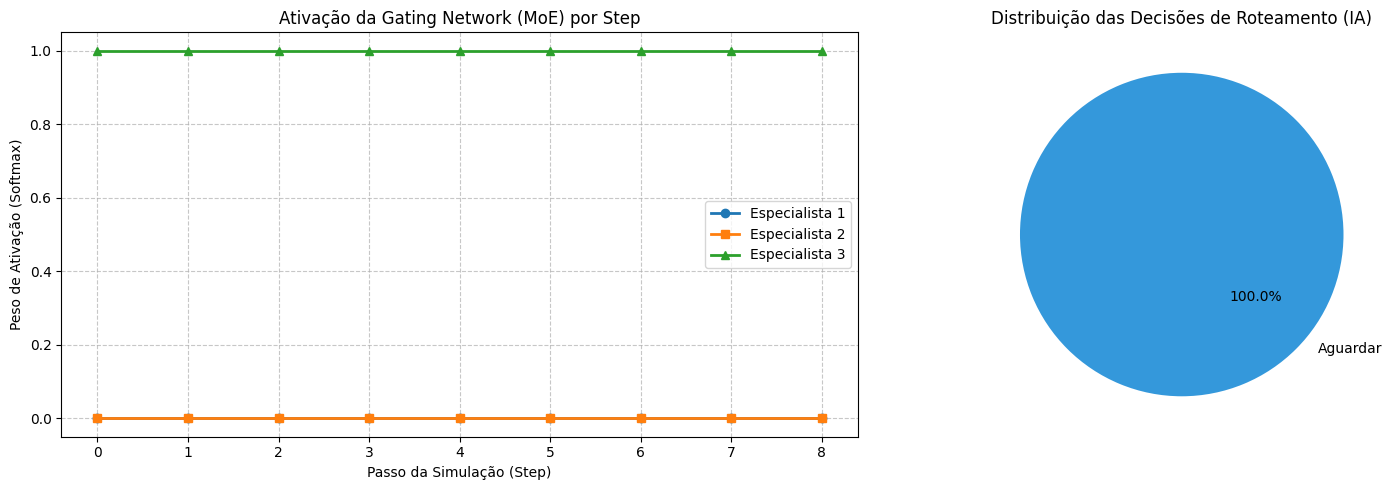

In [11]:
# --- CÉLULA 3: Análise da Arquitetura MoE e Distribuição de Ações ---
from collections import Counter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Ativação dos Especialistas (MoE)
steps_plot = range(len(historico_pesos))
ax1.plot(steps_plot, historico_pesos[:, 0], label='Especialista 1', marker='o', linewidth=2)
ax1.plot(steps_plot, historico_pesos[:, 1], label='Especialista 2', marker='s', linewidth=2)
ax1.plot(steps_plot, historico_pesos[:, 2], label='Especialista 3', marker='^', linewidth=2)
ax1.set_title('Ativação da Gating Network (MoE) por Step', fontsize=12)
ax1.set_xlabel('Passo da Simulação (Step)')
ax1.set_ylabel('Peso de Ativação (Softmax)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Distribuição das Decisões
mapa_acoes_curto = {0: "Aguardar", 1: "B3", 2: "Base", 3: "Slicing"}
contagem_acoes = Counter(historico_acoes)
labels_acoes = [mapa_acoes_curto[acao] for acao in contagem_acoes.keys()]
valores_acoes = list(contagem_acoes.values())

ax2.pie(valores_acoes, labels=labels_acoes, autopct='%1.1f%%', startangle=140, 
        colors=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71'])
ax2.set_title('Distribuição das Decisões de Roteamento (IA)', fontsize=12)

plt.tight_layout()
plt.show()